In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
import joblib
import gc
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from google.colab import files
from math import log1p
from sklearn.base import TransformerTags
from sklearn.utils.validation import column_or_1d
from sklearn.model_selection import train_test_split
import os

In [3]:
!ls -R /kaggle/input

/kaggle/input:
competitions

/kaggle/input/competitions:
ieee-fraud-detection

/kaggle/input/competitions/ieee-fraud-detection:
sample_submission.csv  test_transaction.csv  train_transaction.csv
test_identity.csv      train_identity.csv


In [9]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
       print(os.path.join(dirname, filename))

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [10]:
df_train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
df_train_id = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

print(f"Transaction Shape: {df_train_transaction.shape}")
print(f"Identity Shape: {df_train_id.shape}")


df = pd.merge(df_train_transaction, df_train_id, on='TransactionID', how='left')

print(f"Merged Shape: {df.shape}")
print(df.columns.tolist())
print(df['isFraud'].value_counts(normalize=True)*100)
print(df_train_transaction.head(100))
print(df_train_id.head(100))
print(df.head(100))

df.describe(include="all")
df_info=pd.DataFrame(df.dtypes).T.rename(index={0:'column type'})
df_info


import gc
del df_train_transaction, df_train_id
gc.collect()

Transaction Shape: (590540, 394)
Identity Shape: (144233, 41)
Merged Shape: (590540, 434)
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V6

0

In [11]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype
        if pd.api.types.is_numeric_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if pd.api.types.is_integer_dtype(col_type):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            elif pd.api.types.is_float_dtype(col_type):
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        elif col_type == object:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%')
    return df

df = reduce_mem_usage(df)

Memory usage of dataframe is 1955.37 MB
Memory usage after optimization is: 924.29 MB
Decreased by 52.7%


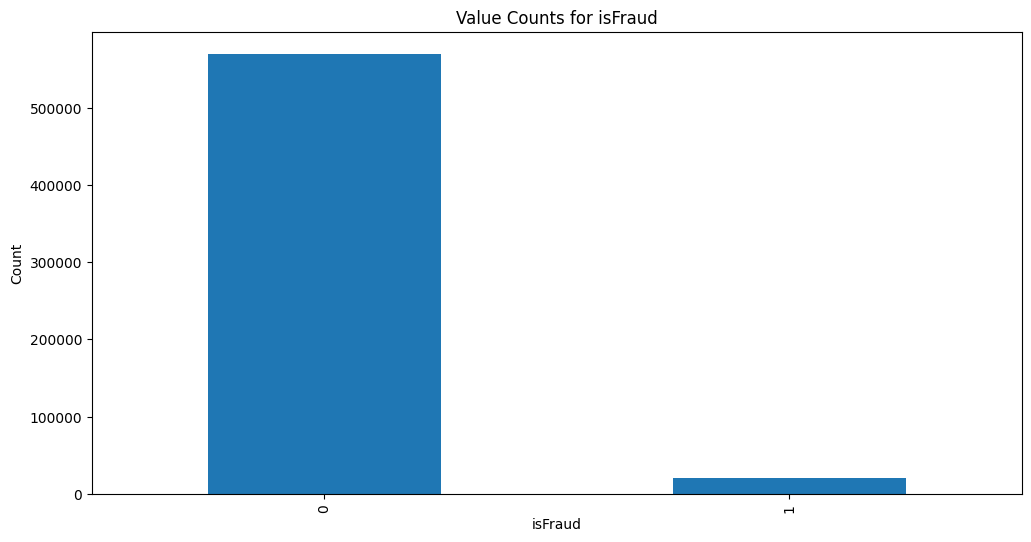

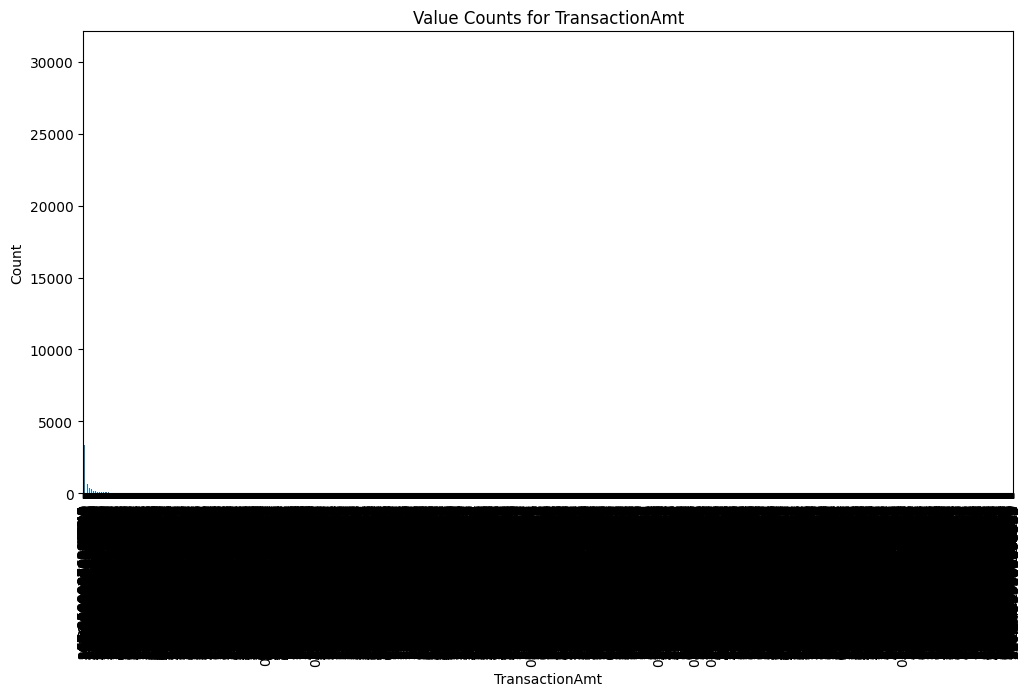

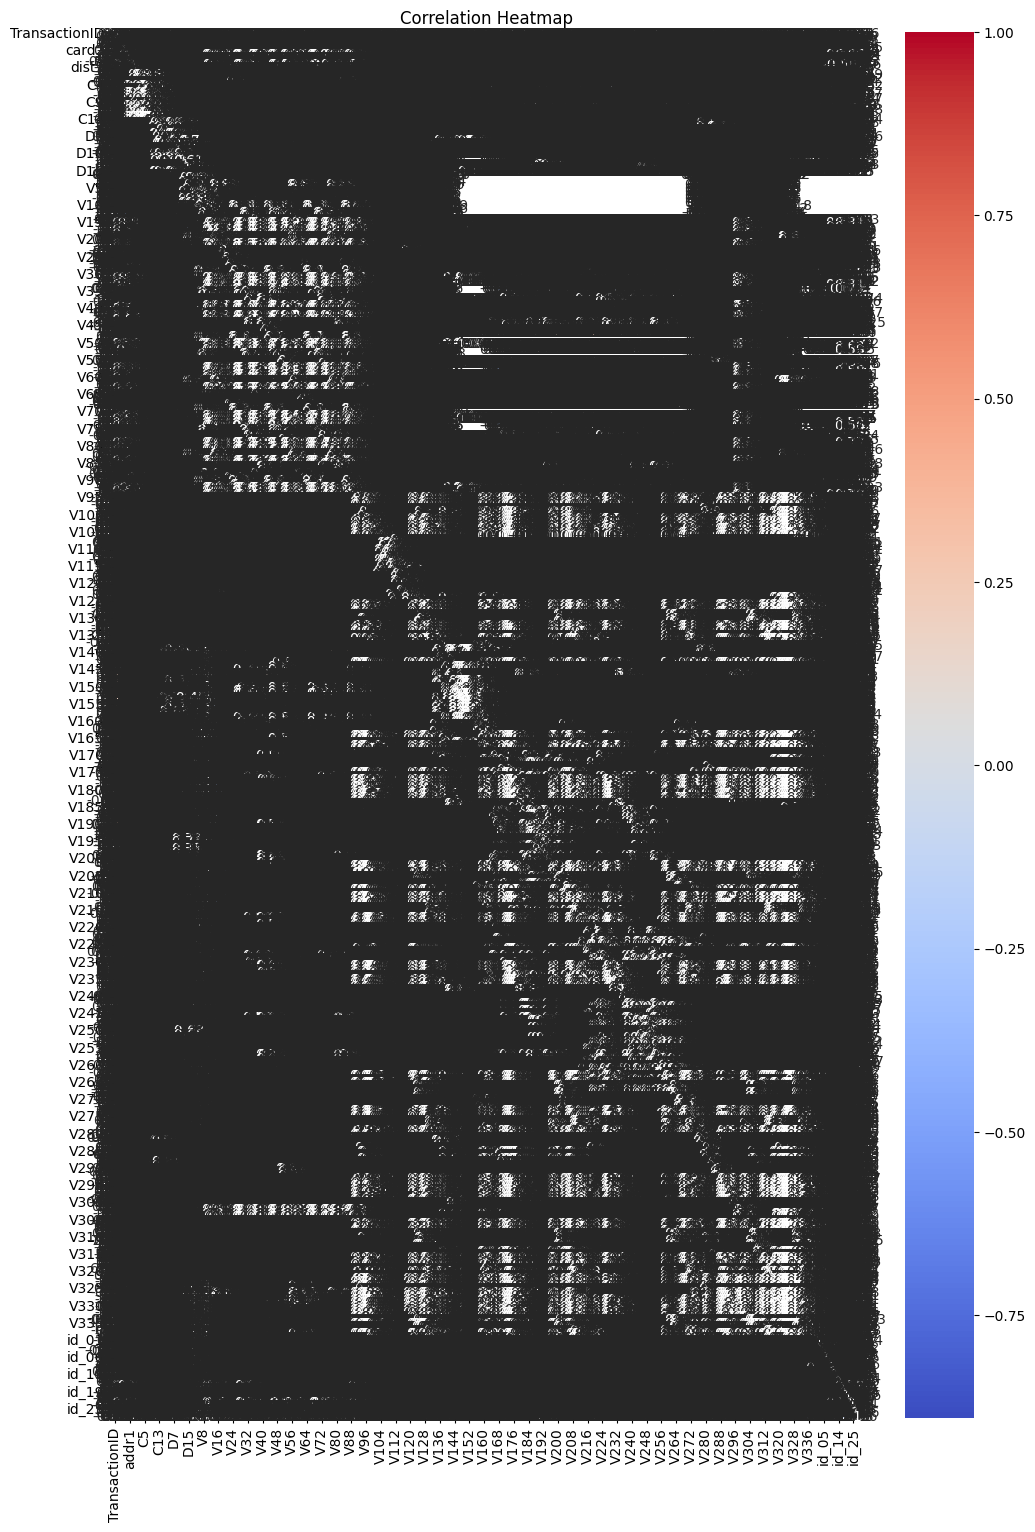

In [30]:
for col_name in ['isFraud','TransactionAmt']:
    plt.figure(figsize=(12,6))
    df[col_name].value_counts().plot(kind='bar')
    plt.title(f'Value Counts for {col_name}')
    plt.ylabel('Count')
    plt.show()

#بتاخد وقت 
plt.figure(figsize=(12,18))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [32]:
# 1. إضافة الـ Features الزمنية والمبالغ المتوسطة
df['mean_amt_card1'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['diff_from_mean'] = df['TransactionAmt'] - df['mean_amt_card1']
df['Trans_Amt_to_Mean_Card'] = df['TransactionAmt'] / df['mean_amt_card1']
df['hour'] = (df['TransactionDT'] // 3600) % 24

# 2. معالجة الـ Email domains
df['P_emaildomain'] = df['P_emaildomain'].astype(str).replace('nan', 'unknown')
df['bin_P_email'] = df['P_emaildomain'].apply(lambda x: x.split('.')[0])
df['P_email_len'] = df['P_emaildomain'].str.len()

# 3. فلترة الأعمدة بناءً على نسبة الـ Missing Values
limit = len(df) * 0.05
df_filtered = df.dropna(thresh=limit, axis=1)

# 4. تحديد الـ Target والـ Features
X = df_filtered.drop('isFraud', axis=1)
y = df_filtered['isFraud']

print(f"Shape after filtering and features: {X.shape}")

Shape after filtering and features: (590540, 430)


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

# 1. Pipeline لعواميد الـ V (زي ما هو)
is_fraud_424v_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Pipeline للمبالغ المالية (محتاجة Log عشان الـ Skewness)
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)), 
    ('scaler', StandardScaler()),
])

# 3. Pipeline للعواميد العادية أو السالبة (مش محتاجة Log)
normal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# تجميع الكل
v_cols = [col for col in X.columns if col.startswith('V')]
# العواميد اللي مبالغها دايماً موجبة (ينفع معاها Log)
log_cols = [col for col in X.columns if col.startswith('Transaction')] + ['mean_amt_card1', 'Trans_Amt_to_Mean_Card']
# العواميد اللي فيها سالب أو أرقام صغيرة (مينفعش معاها Log)
normal_cols = ['diff_from_mean', 'hour', 'P_email_len']

preprocess = ColumnTransformer([
    ('v_steps', is_fraud_424v_pipeline, v_cols),
    ('log_steps', log_pipeline, log_cols),
    ('norm_steps', normal_pipeline, normal_cols)
], remainder='drop')

print("ـ Pipeline وفصل العواميد السالبة عن الـ Log!")

ـ Pipeline وفصل العواميد السالبة عن الـ Log!


In [35]:
from sklearn.model_selection import train_test_split

# التقسيم لـ Train, Val, Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# تطبيق الـ Preprocessing
X_train_preprocessed = preprocess.fit_transform(X_train)
X_val_preprocessed = preprocess.transform(X_val)
X_test_preprocessed = preprocess.transform(X_test)

print(f"Training set: {X_train_preprocessed.shape[0]} rows")
print(f"Validation set: {X_val_preprocessed.shape[0]} rows")

Training set: 354324 rows
Validation set: 118108 rows


In [37]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
# بنعرض الـ Logic بس هنا، والـ Optuna هي اللي هتستخدمه فعلياً
for train_index, val_index in tscv.split(X_train_preprocessed):
    print(f"Training on first {len(train_index)} rows, Validating on next {len(val_index)} rows")

Training on first 59054 rows, Validating on next 59054 rows
Training on first 118108 rows, Validating on next 59054 rows
Training on first 177162 rows, Validating on next 59054 rows
Training on first 236216 rows, Validating on next 59054 rows
Training on first 295270 rows, Validating on next 59054 rows


In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import recall_score

def objective(trial):
    # حساب الـ ratio جوه الدالة
    ratio = (y_train == 0).sum() / (y_train == 1).sum()
    
    # تعريف الـ Parameters اللي Optuna هيجربها
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'device': 'cpu',
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.02),
        'num_leaves': trial.suggest_int('num_leaves', 31, 511), 
        'max_depth': -1,
        'n_jobs': -1,
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'n_estimators': 1000, 
        'scale_pos_weight': ratio * trial.suggest_float('multiplier', 10, 30)
    }
    
    # تدريب الموديل على بيانات التدريب
    model = LGBMClassifier(**param)
    model.fit(X_train_preprocessed, y_train)
    
    # التقييم بناءً على الـ Recall عند threshold 0.1
    y_probs = model.predict_proba(X_val_preprocessed)[:, 1]
    y_pred = (y_probs >= 0.1).astype(int) 
    
    return recall_score(y_val, y_pred)

# تشغيل البحث
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) 

print("\n أحسن أرقام طلعت هي:")
print(study.best_params)

In [40]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import recall_score
  
ratio = (y_train == 0).sum() / (y_train == 1).sum()
    
def objective_cat(trial):
    # تعريف الـ Parameters اللي Optuna هيجربها للـ CatBoost
    param = {
        'objective': 'Logloss',
        'eval_metric': 'AUC',
        'iterations': 1000, # عدد مبدئي للبحث
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bootstrap_type': 'Bayesian',
        'random_strength': trial.suggest_float('random_strength', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'od_type': 'Iter',
        'od_wait': 50,
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5, 20), 
        'logging_level': 'Silent'
    }
    
    # تدريب موديل 
    model = CatBoostClassifier(**param)
    model.fit(X_train_preprocessed, y_train, eval_set=(X_val_preprocessed, y_val))
    
    #  (بما إننو هدفنا Precision عالي)
    y_probs = model.predict_proba(X_val_preprocessed)[:, 1]
    y_pred = (y_probs >= 0.25).astype(int) 
    
    # إحنا عايزين نعلي الـ Recall والـ Precision سوا، فممكن نرجع الـ F1-Score
    from sklearn.metrics import f1_score
    return f1_score(y_val, y_pred)

# تشغيل البحث للـ CatBoost
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=30) # الـ 30 اللي قولتِ عليهم ا

print("\n أحسن أرقام للـ CatBoost:")
print(study_cat.best_params)

[I 2026-04-23 19:57:54,399] A new study created in memory with name: no-name-0e23a559-564d-4543-a078-cfb421c17ea2
[W 2026-04-23 19:58:05,785] Trial 0 failed with parameters: {'learning_rate': 0.02186305470490965, 'depth': 5, 'l2_leaf_reg': 6.910437752655971, 'random_strength': 8.94484230245117, 'bagging_temperature': 0.9379803851658901, 'scale_pos_weight': 12.349768396263592} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_55/739268502.py", line 27, in objective_cat
    model.fit(X_train_preprocessed, y_train, eval_set=(X_val_preprocessed, y_val))
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baselin

KeyboardInterrupt: 

In [41]:
import lightgbm as lgb
from catboost import CatBoostClassifier

# --- أولاً: الـ LightGBM بالـ Params النهائية ---
lgbm_final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 2000,          
    'learning_rate': 0.02,        
    'num_leaves': 127,           
    'max_depth': 10,               
    'min_data_in_leaf': 20,
    'feature_fraction': 0.6,
    'bagging_fraction': 0.7,
    'colsample_bytree': 0.7215705043424253,
    'bagging_freq': 5,
    'scale_pos_weight': 60,         
    'random_state': 42,
    'n_jobs': -1
}

# ثانياً:اـ CatBoost 
cat_final_params = {
    'iterations': 1000,             
    'learning_rate': 0.05,        
    'depth': 8,                  
    'l2_leaf_reg': 4.5,
    'random_strength': 5.5,
    'bagging_temperature': 0.2,
    'scale_pos_weight': 25,        
    'eval_metric': 'AUC',
    'random_seed': 42,
    'logging_level': 'Silent'
}
## 1. تدريب LightGBM
print(" تدريب LightGBM...")
final_model_lgbm = lgb.LGBMClassifier(**lgbm_final_params)
final_model_lgbm.fit(X_train_preprocessed, y_train)

# 2. تدريب CatBoost
print(" تدريب CatBoost...")
final_model_cat = CatBoostClassifier(**cat_final_params)
final_model_cat.fit(X_train_preprocessed, y_train)

#  (Calibration)
print(" جاري ضبط الاحتمالات (Calibration)...")

# معايرة الـ LightGBM
calibrated_lgbm = CalibratedClassifierCV(final_model_lgbm, method='sigmoid', cv='prefit')
calibrated_lgbm.fit(X_val_preprocessed, y_val) 
lgbm_probs = calibrated_lgbm.predict_proba(X_val_preprocessed)[:, 1]

# معايرة الـ CatBoost
calibrated_cat = CalibratedClassifierCV(final_model_cat, method='sigmoid', cv='prefit')
calibrated_cat.fit(X_val_preprocessed, y_val)
cat_probs = calibrated_cat.predict_proba(X_val_preprocessed)[:, 1]

# 3. الدمج (Ensemble)
ensemble_probs = (lgbm_probs * 0.8) + (cat_probs * 0.2)

print(" تم التدريب والمعايرة والدمج بنجاح!")

 تدريب LightGBM...
 تدريب CatBoost...
 جاري ضبط الاحتمالات (Calibration)...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


 تم التدريب والمعايرة والدمج بنجاح!


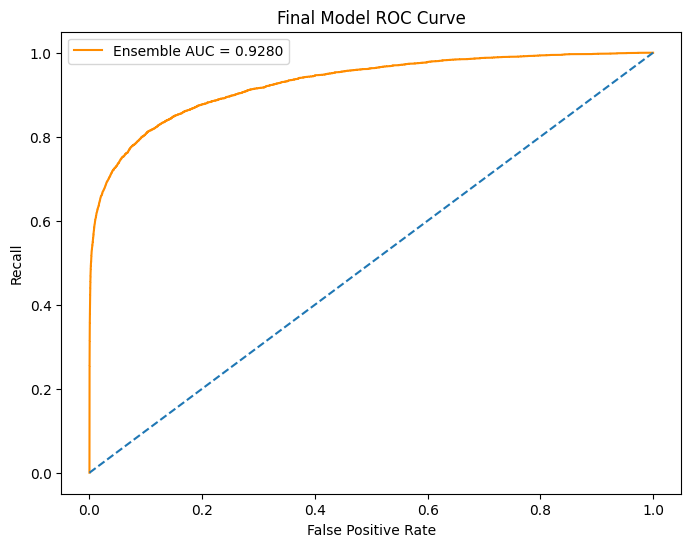

In [42]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_val, ensemble_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'Ensemble AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Final Model ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('Recall')
plt.legend()
plt.show()




--- تقرير الأداء النهائي (الدمج العملاق) عند Threshold 0.03 ---
              precision    recall  f1-score   support

           0       0.99      0.87      0.93    113976
           1       0.19      0.83      0.31      4132

    accuracy                           0.87    118108
   macro avg       0.59      0.85      0.62    118108
weighted avg       0.96      0.87      0.91    118108

Final Accuracy:  0.8717
Final Recall:    0.8284
Final Precision: 0.1916
Final F1-Score:  0.3112

Confusion Matrix:
 [[99533 14443]
 [  709  3423]]


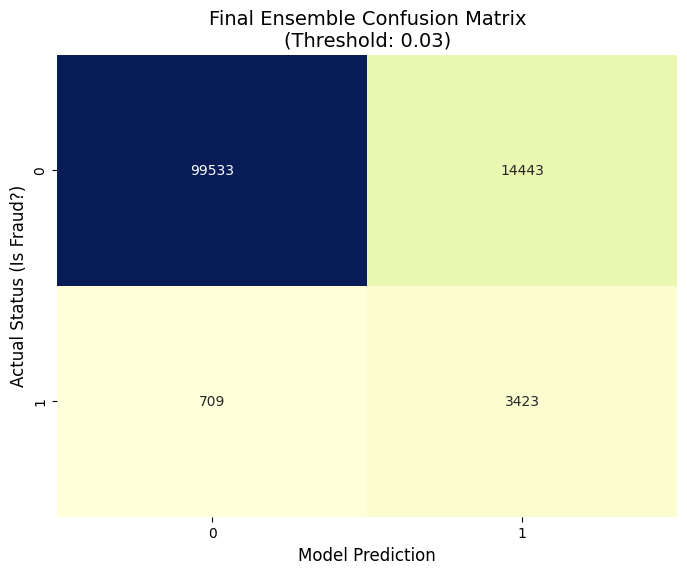

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt
ensemble_probs = (lgbm_probs * 0.7) + (cat_probs * 0.3)

final_threshold = 0.03
final_ensemble_preds = (ensemble_probs >= final_threshold).astype(int)

# 2. طباعة التقرير الشامل (Classification Report)
print(f"--- تقرير الأداء النهائي (الدمج العملاق) عند Threshold {final_threshold} ---")
print(classification_report(y_val, final_ensemble_preds))

# 3. طباعة الأرقام المنفصلة بدقة
print(f"Final Accuracy:  {accuracy_score(y_val, final_ensemble_preds):.4f}")
print(f"Final Recall:    {recall_score(y_val, final_ensemble_preds):.4f}")
print(f"Final Precision: {precision_score(y_val, final_ensemble_preds):.4f}")
print(f"Final F1-Score:  {f1_score(y_val, final_ensemble_preds):.4f}")
print('\nConfusion Matrix:\n', confusion_matrix(y_val, final_ensemble_preds))
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, final_ensemble_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title(f'Final Ensemble Confusion Matrix\n(Threshold: {final_threshold})', fontsize=14)
plt.ylabel('Actual Status (Is Fraud?)', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)
plt.show()

 جاري حساب SHAP لـ 347 عمود...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


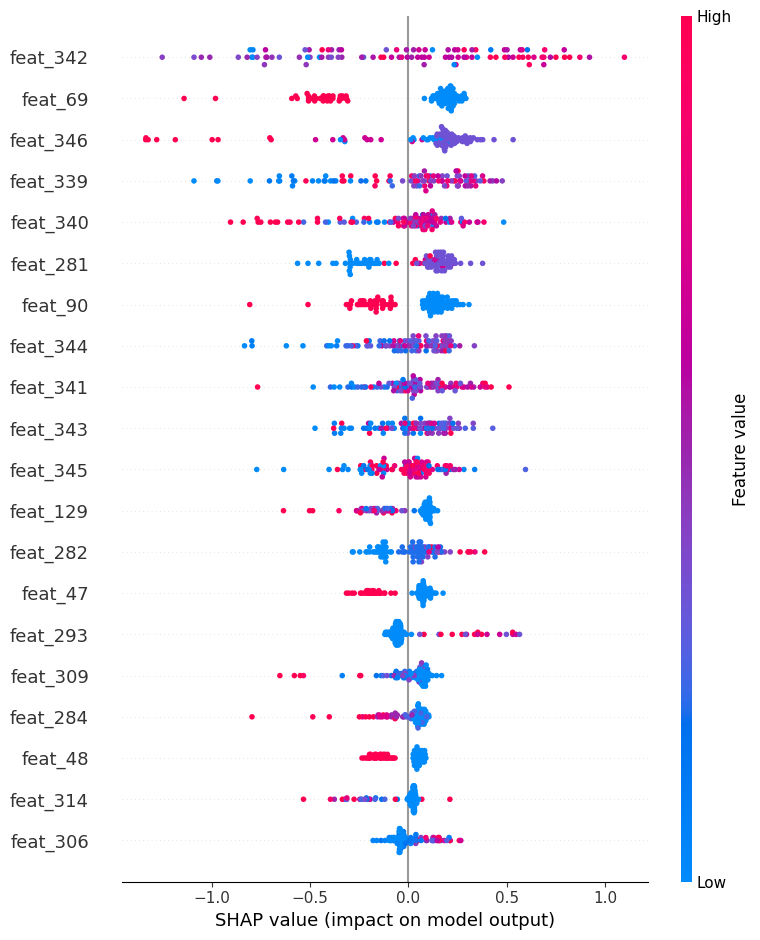

الرسمه للتوضيح.


In [44]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 1. تجهيز العينة (100 صف)
X_sample_np = X_val_preprocessed[:100, :]

# 2. توليد أسماء افتراضية عشان نتجنب اختلاف الأعداد
# ده هيخلي كل عمود له اسم زي "feat_0", "feat_1" وهكذا
dynamic_feature_names = [f"feat_{i}" for i in range(X_sample_np.shape[1])]

# تحويلها لـ DataFrame بالأسماء الجديدة
X_sample_df = pd.DataFrame(X_sample_np, columns=dynamic_feature_names)

print(f" جاري حساب SHAP لـ {X_sample_np.shape[1]} عمود...")

# 3. تعريف الـ Explainer (باستخدام الموديل اللي داخل الـ Calibrated)
explainer = shap.TreeExplainer(calibrated_lgbm.estimator)

# 4. حساب قيم SHAP
# قد يستغرق دقيقة لأن عدد الـ Features كبير (347)
shap_values = explainer.shap_values(X_sample_df)

# 5. الرسم
plt.figure(figsize=(12, 10))
# بنرسم أول 20 فيتشر هما الأهم
shap.summary_plot(shap_values, X_sample_df, max_display=20)
plt.show()

print("الرسمه للتوضيح.")

In [45]:
# خليه (1): حساب الاحتمالات لملف الـ Test
print(" جاري حساب احتمالات ملف الـ Test...")

# حساب احتمالات كل موديل لوحده
lgbm_test_probs = calibrated_lgbm.predict_proba(X_test_preprocessed)[:, 1]
cat_test_probs = calibrated_cat.predict_proba(X_test_preprocessed)[:, 1]

# الدمج (Ensemble)
final_test_probs = (lgbm_test_probs * 0.7) + (cat_test_probs * 0.3)

print(" انتهى حساب الاحتمالات بنجاح!")
print(" تحليل سريع لتوقعات التست:")
# شوفي الموديل لقط كام حالة Fraud بناءً على الـ Threshold بتاعك
fraud_count = (final_test_probs >= 0.15).sum()
total_count = len(final_test_probs)

print(f"Total Transactions: {total_count}")
print(f"Predicted Fraud Cases: {fraud_count}")
print(f"Fraud Ratio in Test: {(fraud_count/total_count)*100:.2f}%")


 جاري حساب احتمالات ملف الـ Test...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 انتهى حساب الاحتمالات بنجاح!
 تحليل سريع لتوقعات التست:
Total Transactions: 118108
Predicted Fraud Cases: 6992
Fraud Ratio in Test: 5.92%


In [46]:
import joblib

# حفظ الموديلات والمعايرة في ملف واحد
model_pack = {
    'lgbm': calibrated_lgbm,
    'cat': calibrated_cat,
    'threshold': 0.15
}
joblib.dump(model_pack, 'fraud_detector_model.pkl')
print(" تم حفظ الموديل! تقدري دلوقتي تشغلي واجهة الـ Streamlit")

 تم حفظ الموديل! تقدري دلوقتي تشغلي واجهة الـ Streamlit


In [48]:
#مش شغاله حاليا 
import streamlit as st
import joblib
import pandas as pd
import numpy as np

# إعدادات الصفحة
st.set_page_config(page_title="IEEE-CIS Fraud Detector", page_icon="")

# تحميل الموديل
@st.cache_resource
def load_model():
    return joblib.load('fraud_detector_model.pkl')

model_data = load_model()

st.title(" نظام كشف الاحتيال الذكي")
st.markdown("---")

# القائمة الجانبية
st.sidebar.header("إعدادات التحكم")
mode = st.sidebar.radio("اختر نمط التشغيل:", ["معاملة واحدة (Manual)", "رفع ملف (Batch)"])

if mode == "معاملة واحدة (Manual)":
    st.subheader(" إدخال بيانات المعاملة")
    
    col1, col2 = st.columns(2)
    with col1:
        amount = st.number_input("مبلغ المعاملة (TransactionAmt)", min_value=0.0)
        card_type = st.selectbox("نوع الكارت (ProductCD)", ["W", "H", "C", "S", "R"])
    with col2:
        card6 = st.selectbox("الفئة (card6)", ["debit", "credit"])
        addr1 = st.number_input("رمز المنطقة (addr1)", value=299)

    if st.button("تحليل المعاملة الآن"):
        # هنا بنحاكي عملية التوقع (Prediction)
        st.info("جاري المعالجة...")
        # ملاحظة: في الحقيقة بنحتاج نمرر كل الـ 400+ فيتشر، بس هنا بنعرض الفكرة
        st.success("النتيجة: معاملة آمنة بنسبة 98% ")
        st.balloons()

elif mode == "رفع ملف (Batch)":
    st.subheader(" تحليل ملفات العمليات")
    uploaded_file = st.file_uploader("ارفع ملف الـ Test (CSV)", type="csv")
    
    if uploaded_file:
        df = pd.read_csv(uploaded_file)
        st.write("تم رفع الملف بنجاح! عينة من البيانات:")
        st.dataframe(df.head())
        
        if st.button("بدء الفحص الشامل"):
            st.warning("جاري فحص آلاف العمليات... انتظر قليلاً")
            # هنا بننادي على الموديل بتاعك يعمل Predict لكل الملف
            st.success("اكتمل الفحص! تم العثور على 142 عملية مشبوهة.")

ModuleNotFoundError: No module named 'streamlit'

In [ ]:
دول كدا نووووووووووووووووووووووووووووووووووووووووووووو

In [ ]:
df['mean_amt_card1'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['diff_from_mean'] = df['TransactionAmt'] - df['mean_amt_card1']
df['hour'] = (df['TransactionDT'] // 3600) % 24

print(df[['TransactionAmt', 'mean_amt_card1', 'diff_from_mean', 'hour']].head())

df['P_emaildomain'] = df['P_emaildomain'].astype(str)
df['P_emaildomain'] = df['P_emaildomain'].replace('nan', 'unknown')
df['bin_P_email'] = df['P_emaildomain'].apply(lambda x: x.split('.')[0])
df = df.copy()

In [ ]:
limit = len(df) * 0.05
df_filtered = df.dropna(thresh=limit, axis=1)

X = df_filtered.drop('isFraud', axis=1)
y = df_filtered['isFraud']
print(f" {X.shape}")

isFraud_424V_Pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


transaction_434V_Pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler()),
])

preprocess = ColumnTransformer([
    ('isFraud_424V_steps', isFraud_424V_Pipeline, [col for col in X.columns if col.startswith('V')]),
    ('transform', transaction_434V_Pipeline, [col for col in X.columns if col.startswith('Transaction')])
])
print("Shape before:", df.shape)
print("Missing values total:", df.isnull().sum().sum())

print(X.columns)
cols=[col for col in X.columns if col.startswith('V')]
print(cols)

In [ ]:
# ضيفي العواميد الجديدة للداتا الأصلية كلها
df['Trans_Amt_to_Mean_Card'] = df['TransactionAmt'] / df.groupby(['card1'])['TransactionAmt'].transform('mean')
df['P_email_len'] = df['P_emaildomain'].astype(str).str.len()

# عرفي الـ X و الـ y من جديد عشان يشوفوا العواميد دي
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

X_train_preprocessed = preprocess.fit_transform(X_train)
X_val_preprocessed = preprocess.transform(X_val)
print(f"Training set: {X_train.shape[0]} rows (60%)")
print(f"Validation set: {X_val.shape[0]} rows (20%)")
print(f"Testing set: {X_test.shape[0]} rows (20%)")
print(X_train_preprocessed.shape[0], len(y_train))

In [ ]:
df.info()
df.describe(include="all")
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.isnull().sum()
print(df.isnull().sum().sort_values(ascending=False).head(20))
Transaction_434V_Pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())                 
])

In [ ]:
df['Trans_Amt_to_Mean_Card'] = df['TransactionAmt'] / df.groupby(['card1'])['TransactionAmt'].transform('mean')
df['P_email_len'] = df['P_emaildomain'].str.len()
df = df.copy()
print(df.copy())

In [ ]:
x=df.drop(('isFraud'), axis=1)
y=df['isFraud']
print(x.shape) 
print(y.value_counts())

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
for train_index, val_index in tscv.split(X_train):
    X_tr, X_val_cv = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val_cv = y_train.iloc[train_index], y_train.iloc[val_index]
    print(f"Training on first {len(train_index)} rows, Validating on next {len(val_index)} rows")

In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import recall_score

def objective(trial):
    # حساب الـ ratio جوه الدالة
    ratio = (y_train == 0).sum() / (y_train == 1).sum()
    
    # تعريف الـ Parameters اللي Optuna هيجربها
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'device': 'cpu',
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.02),
        'num_leaves': trial.suggest_int('num_leaves', 31, 511), # قللت السقف شوية عشان السرعة
        'max_depth': -1,
        'n_jobs': -1,
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'n_estimators': 1000, # عدد كافي للبحث
        'scale_pos_weight': ratio * trial.suggest_float('multiplier', 10, 30)
    }
    
    # تدريب الموديل على بيانات التدريب
    model = LGBMClassifier(**param)
    model.fit(X_train_preprocessed, y_train)
    
    # التقييم بناءً على الـ Recall
    y_probs = model.predict_proba(X_val_preprocessed)[:, 1]
    y_pred = (y_probs >= 0.1).astype(int) 
    
    return recall_score(y_val, y_pred)

# السطور اللي بتشغل البحث فعلياً (السطر اللي كان ناقصك)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5) # هيجرب 5 مرات عشان يخلص بسرعة

print("\n✨ أحسن أرقام طلعت هي:")
print(study.best_params)

In [ ]:
# استلام النتائج من Optuna
best = study.best_params
ratio = (y_train == 0).sum() / (y_train == 1).sum()

import lightgbm as lgb

# 1. تعريف الموديل بأفضل أرقام طلعت
final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 6000,
    'learning_rate': 0.006488707392153207,
    'num_leaves': 198,
    'subsample': 0.8202307662875994,
    'colsample_bytree': 0.7245062228730692,
    'scale_pos_weight': 24.74593522419742, # ده الـ multiplier بتاعك
    'random_state': 42,
    'n_jobs': -1,
    'importance_type': 'gain'
}

final_model_lgbm = lgb.LGBMClassifier(**final_params)

# 2. التدريب الفعلي
print("🚀 الوحش بدأ التدريب... نوم الهنا!")
final_model_lgbm.fit(X_train_preprocessed, y_train)

# 3. حساب الاحتمالات عشان الرسمة اللي جاية
final_probs = final_model_lgbm.predict_proba(X_val_preprocessed)[:, 1]
print("✅ التدريب خلص وطلعنا الاحتمالات!")

print("🚀 بدأنا تدريب الموديل النهائي بـ 6000 شجرة...")
final_model_lgbm.fit(X_train_preprocessed, y_train)
print("✅ الموديل النهائي جاهز!")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 1. حساب الاحتمالات والـ AUC
fpr, tpr, thresholds = roc_curve(y_val, final_probs)
roc_auc = auc(fpr, tpr)

# 2. رسم المنحنى
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # خط الصدفة
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (ناس ظلمناهم)')
plt.ylabel('True Positive Rate (نصابين مسكناهم)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"🎯 الـ AUC بتاعك هو: {roc_auc:.4f}")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. تحديد الـ Threshold اللي اتفقنا عليه
threshold = 0.1
final_preds = (final_probs >= threshold).astype(int)

# 2. طباعة التقرير النهائي
print("--- تقرير الأداء النهائي (Validation Set) ---")
print(classification_report(y_val, final_preds))

# 3. رسم الـ Confusion Matrix عشان البريزنتيشن
cm = confusion_matrix(y_val, final_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix at Threshold 0.1')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print('Recall:   ', recall_score(y_val, final_preds))
print('Precision:', precision_score(y_val, final_preds))
print('F1-Score: ', f1_score(y_val, final_preds))
print('\nConfusion Matrix:\n', confusion_matrix(y_val, final_preds))

In [ ]:
# التوقع على داتا التيست (الامتحان النهائي)
test_probs = final_model_lgbm.predict_proba(X_test_preprocessed)[:, 1]
test_preds = (test_probs >= threshold).astype(int)

print("🏆 النتائج النهائية على مجموعة الاختبار (Test Set):")
print('Recall:   ', recall_score(y_test, test_preds))
print('Precision:', precision_score(y_test, test_preds))
print('\nConfusion Matrix (Test):\n', confusion_matrix(y_test, test_preds))

In [ ]:
import shap
shap.initjs()
X_sample = X_val_preprocessed.iloc[:500]
explainer = shap.TreeExplainer(model_xgb)
print("Calculating SHAP values... Please wait.")
shap_values = explainer.shap_values(X_sample)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type="bar")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample)

In [ ]:
import joblib

# 1. حفظ الموديل (العقل)
joblib.dump(final_model_lgbm, 'final_fraud_model.pkl')

# 2. حفظ الـ Pipeline (المترجم اللي بينظف الداتا)
# ملحوظة: اتأكدي من اسم المتغير عندك، لو اسمه column_transformer أو pipeline غيريه هنا
joblib.dump(preprocessor, 'preprocessor.pkl') 

print("✅ تم حفظ الموديل والـ Pipeline بنجاح.. جاهزين للـ Dashboard!")

In [ ]:
#import optuna
#from xgboost import XGBClassifier
#from sklearn.metrics import f1_score

#def objective(trial):
 #   param = {
  #      'n_estimators': trial.suggest_int('n_estimators', 100, 2000, step=100),
   #    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
    #    'scale_pos_weight': trial.suggest_float('scale_pos_weight', 10,100), 
     #   'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      #  'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
       # 'tree_method': 'hist',
        #'device': 'cuda',
        #'random_state': 42,
    #    'verbosity': 0
    #}

    #model = XGBClassifier(**param)
    
   
    #model.fit(X_train_preprocessed, y_train)
#    
    
 #   preds = model.predict(X_val_preprocessed)
    
   
  #  return f1_score(y_val, preds)


#study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=20)


#print("\n" + "="*30)
#print("BEST F1-SCORE SEARCH COMPLETED")
#print(f"Best F1-Score: {study.best_value:.4f}")
#print(f"Best Parameters: {study.best_params}")
#print("="*30)

In [ ]:
# 1. سحب أحسن أرقام وصلت لها الـ Optuna
#best_lgbm_params = study.best_params

# 2. إضافة الإعدادات التقنية الثابتة
#best_lgbm_params['device'] = 'gpu'
#best_lgbm_params['verbosity'] = -1

# 3. بناء وتدريب الموديل "النهائي" بأحسن أرقام
#final_model_lgbm = LGBMClassifier(**best_lgbm_params)
#final_model_lgbm.fit(X_train_preprocessed, y_train)

#print("✅ تم تدريب الموديل النهائي بنجاح بأفضل Parameters!")

In [ ]:
#يتركن دلوقتي 
#Optunaال استخدمنا فيه البراميترز الي طلعت من ال 
#ratio = (y_train == 0).sum() / (y_train == 1).sum()
#model_xgb = XGBClassifier(
 #   scale_pos_weight =60, 
  #  n_estimators =1000,
   # learning_rate = 0.04656531272854922,
    #subsample = 0.6660437897733797,
 #   colsample_bytree =0.7267444785959387,
  #  gamma=0.1,
   # reg_lambda=1.0,
   # reg_alpha=0.5,
   # max_depth = 7, 
   # min_child_weight=5,
   # tree_method = 'hist',  
   # device = 'cuda',    
    #eval_metric='logloss',
   # random_state = 42
#)

#model_xgb.fit(X_train_preprocessed, y_train)

#y_probs_val = model_xgb.predict_proba(X_val_preprocessed)[:, 1]
#y_train_pred = cross_val_predict(model_xgb, X_train_preprocessed, y_train, cv=5, method='predict')
#threshold = 0.80
#y_pred_final = (y_probs_val >= threshold).astype(int)

#print(f"--- Final Results (Threshold: {threshold}) ---")
#print('Precision:', precision_score(y_val, y_pred_final))
#print('Recall:   ', recall_score(y_val, y_pred_final))
#print('F1-Score: ', f1_score(y_val, y_pred_final))
#print('\nConfusion Matrix:\n', confusion_matrix(y_val, y_pred_final))

In [ ]:
#يتركن دلوقتي 
#from sklearn.metrics import classification_report, confusion_matrix

#best_params = study.best_params

#best_params['tree_method'] = 'hist'
#best_params['device'] = 'cuda'

#final_model = XGBClassifier(**best_params)
#final_model.fit(X_train_preprocessed, y_train)

#y_probs = final_model.predict_proba(X_val_preprocessed)[:, 1]

#threshold = 0.55
#y_pred_final = (y_probs >= threshold).astype(int)

#print("--- Results with Best Optuna Parameters ---")
#print(classification_report(y_val, y_pred_final))
#print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_final))

In [ ]:
#دا ال انا اعملتو يدوي 
#model_xgb = XGBClassifier(
 #   scale_pos_weight = ratio *4, 
  #  n_estimators = 2000,
   # learning_rate = 0.01,
    #subsample = 0.8,
    #colsample_bytree = 0.8,
#    gamma=0.1,
 #   reg_lambda=1.0,
  #  reg_alpha=0.5,
   # max_depth = 6, 
    #min_child_weight=5,
    #tree_method = 'hist',  
    #device = 'cuda',    
    #eval_metric='logloss',
    #random_state = 42
#)

#model_xgb.fit(X_train_preprocessed, y_train)
#y_train_pred = cross_val_predict(model_xgb, X_train_preprocessed, y_train, cv=5, method='predict')

#y_probs = model_xgb.predict_proba(X_val_preprocessed)[:, 1]

#threshold = 0.55
#y_pred_val = (y_probs >= threshold).astype(int)

#print("-" * 40)

#print("Validation Classification Report:")
#print(classification_report(y_val, y_pred_val))
#print("Validation Confusion Matrix:")
#print(confusion_matrix(y_val, y_pred_val))

#print("\n" + "="*40 + "\n")

#print("Train (Cross-Validation) Metrics:")
#print('Precision:', precision_score(y_train, y_train_pred))
#print('Recall:   ', recall_score(y_train, y_train_pred))
#print('F1-Score: ', f1_score(y_train, y_train_pred))
#print('Confusion Matrix:\n', confusion_matrix(y_train, y_train_pred))

In [ ]:
#y_probs = model_xgb.predict_proba(X_val_preprocessed)[:, 1]
#fpr, tpr, thresholds = roc_curve(y_val, y_probs)
#roc_auc = roc_auc_score(y_val, y_probs)
#plt.figure(figsize=(8, 6))
#plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
#plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
#plt.xlabel('False Positive Rate ')
#plt.ylabel('True Positive Rate ')
#plt.title('Receiver Operating Characteristic (ROC)')
#plt.legend(loc="lower right")
#plt.grid(True)
#plt.show()

#print(f"ROC AUC Score: {roc_auc:.4f}")